In [1]:
from rubin_scheduler.scheduler.utils import Footprint, make_rolling_footprints, CurrentAreaMap

from new_sky_area import SmallerFootprint

import healpy as hp
%matplotlib inline
import numpy as np


import matplotlib.pylab as plt

import pandas as pd

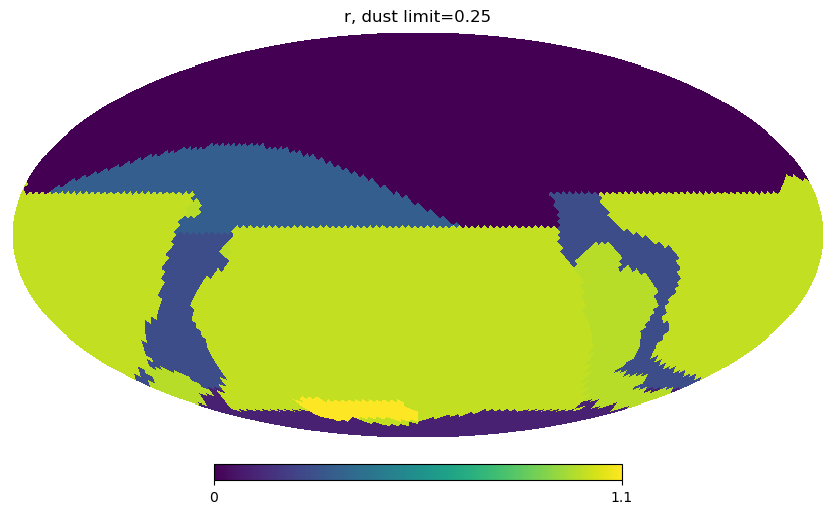

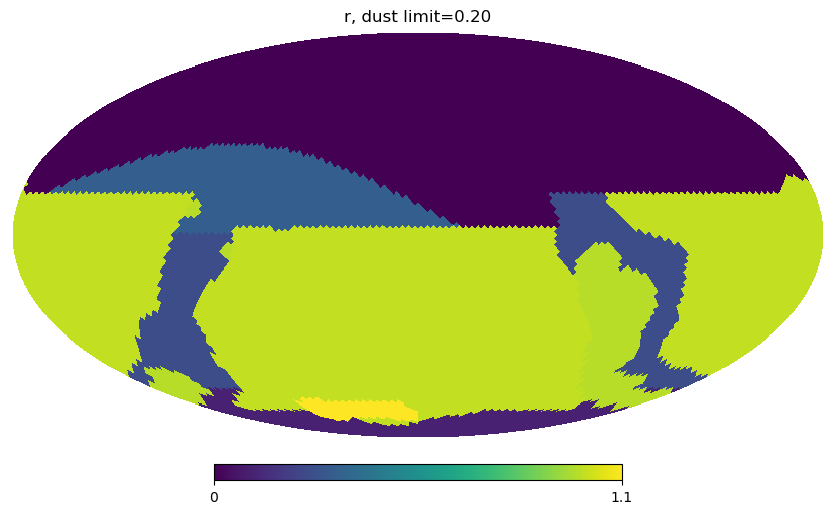

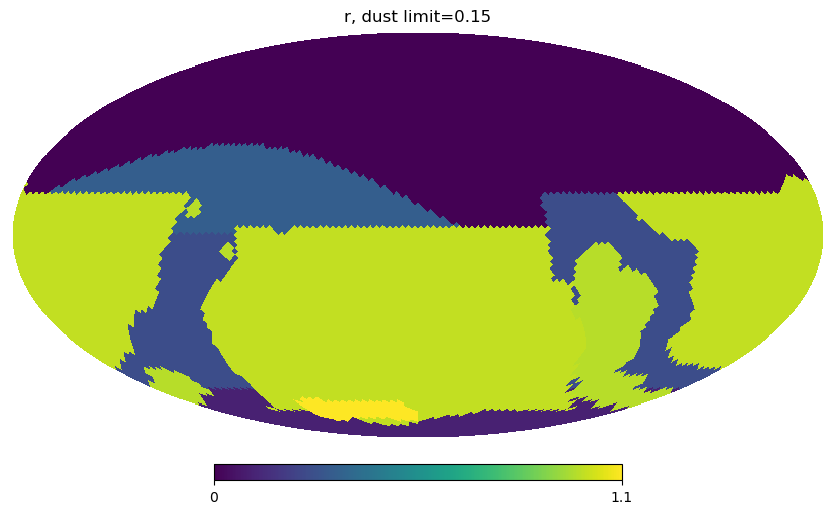

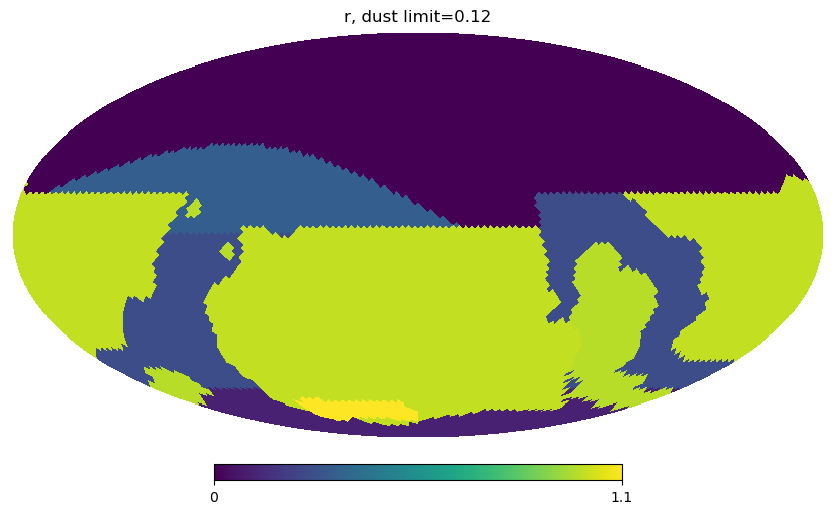

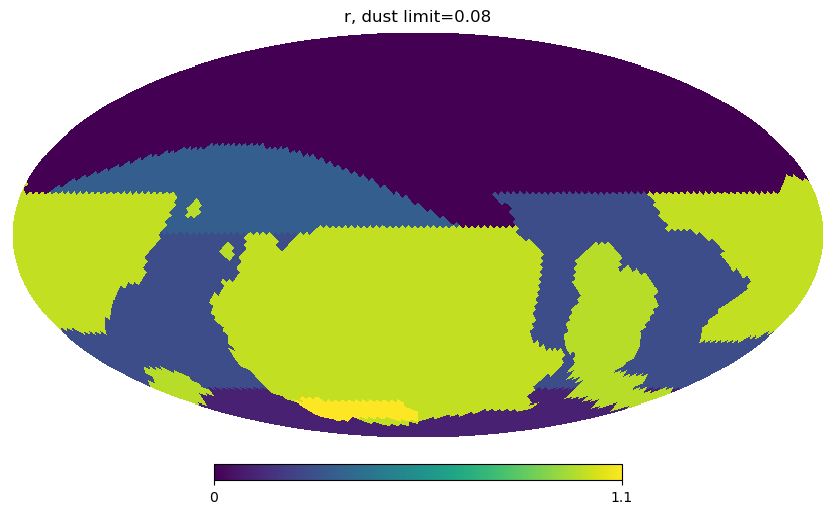

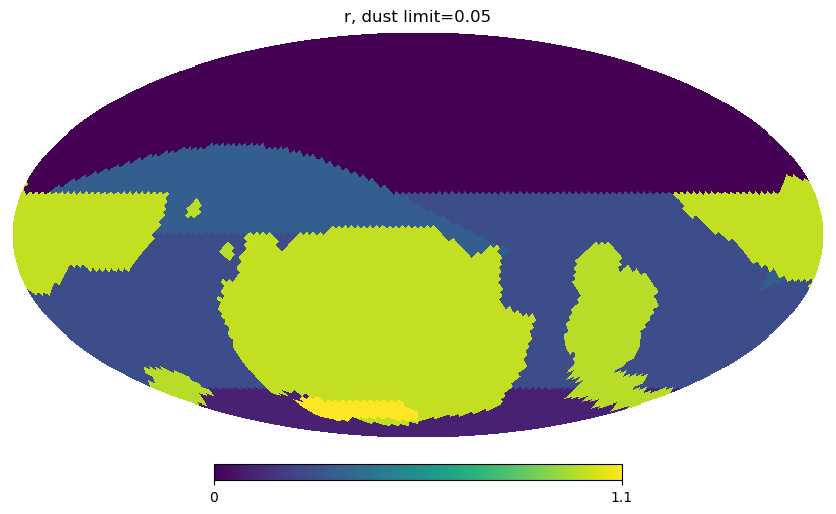

In [2]:
nside = 32
dust_limits = [0.25, 0.199, 0.15, 0.12, 0.08, 0.05]
df = pd.DataFrame()
for dust_limit in dust_limits:
    sag = SmallerFootprint(dust_limit=dust_limit)
    sky_maps, labels = sag.return_maps()

    areas = {}
    area = hp.nside2pixarea(nside, degrees=True)
    label_int = np.zeros(hp.nside2npix(nside))
    for i,label in enumerate(np.unique(labels)):
        indx = np.where(labels == label)[0]
        label_int[indx] = i
        #print(i, label)
        areas[str(label)] = float(indx.size *area)
    temp = pd.DataFrame.from_dict(areas,orient="index", columns=[dust_limit])
    df[dust_limit] = temp[dust_limit]
    hp.mollview(sky_maps['r'], title='r, dust limit=%.2f' % dust_limit)


In [3]:
df

,0.250,0.199,0.150,0.120,0.080,0.050
,14083.347367,14076.633017,14019.561050,13985.989304,13824.844924,13405.198101
LMC_SMC,302.145712,302.145712,302.145712,302.145712,302.145712,302.145712
bulgy,1695.373163,1772.588179,1873.303416,1937.089733,1997.518876,1997.518876
dusty_plane,2521.238110,3038.242996,3907.751212,4730.258984,6724.420685,9735.806284
euclid_overlap,104.072412,104.072412,104.072412,107.429587,241.716570,993.723676
lowdust,18293.244291,17645.309597,16591.156779,15634.362023,13364.912006,9655.234095
nes,3102.029313,3112.100836,3149.029757,3189.315852,3279.959565,3521.676135
scp,1077.653040,1128.010659,1232.083071,1292.512214,1443.585070,1567.800529
virgo,73.857841,73.857841,73.857841,73.857841,73.857841,73.857841


In [4]:
sky = CurrentAreaMap(nside=nside)
footprints_hp_array, labels = sky.return_maps()

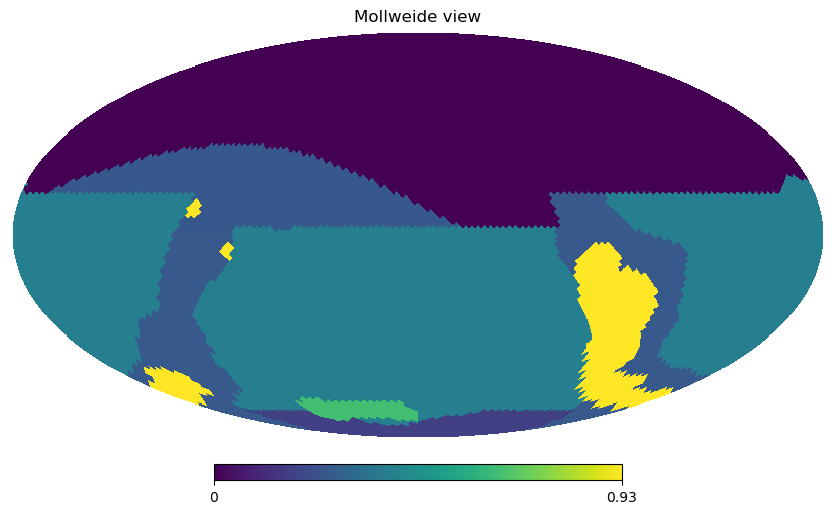

In [5]:
hp.mollview(footprints_hp_array['g'])

In [6]:
sag = SmallerFootprint(dust_limit=0.199)
sky_maps, labels = sag.return_maps()

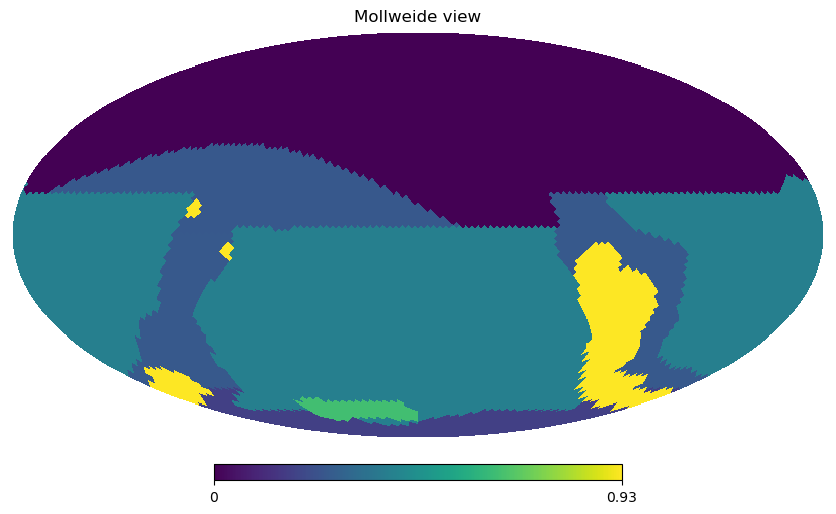

In [7]:
hp.mollview(sky_maps['g'])